## <h1 style="color: blue;">🩺Healthcare Data Analysis 1</h1>

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("healthcare_dataset.csv")

In [29]:
df.head() # By default, it shows the first 5 rows. Use df.tail() to display the last 5 rows.

,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04
4,5,60,Male,130,96,206,39.3,Diabetes,NaN,2024-01-05


In [30]:
# Quick look at the dataset structure
print("Dataset shape:", df.shape)
print("\nData types:") # Displays the data types of each column
print(df.dtypes)

Dataset shape: (500, 10)

Data types:
Patient_ID             int64
Age                    int64
Gender                object
Blood_Pressure         int64
Heart_Rate             int64
Cholesterol_Level      int64
BMI                  float64
Diagnosis             object
Treatment_Plan        object
Follow_Up_Date        object
dtype: object


In [31]:
# Summary statistics
print("\nSummary statistics:")
print(df.describe()) # Displays basic statistical summary


Summary statistics:
       Patient_ID        Age  Blood_Pressure  Heart_Rate  Cholesterol_Level  \
count  500.000000  500.00000      500.000000  500.000000         500.000000   
mean   250.500000   48.87400      133.024000   79.874000         225.806000   
std    144.481833   29.56983       25.665246   11.354293          44.964608   
min      1.000000    0.00000       90.000000   60.000000         150.000000   
25%    125.750000   23.00000      112.000000   70.750000         186.000000   
50%    250.500000   50.00000      132.000000   79.500000         226.000000   
75%    375.250000   72.25000      154.000000   90.000000         267.000000   
max    500.000000   99.00000      179.000000   99.000000         299.000000   

              BMI  
count  500.000000  
mean    29.430400  
std      6.132838  
min     18.600000  
25%     24.100000  
50%     29.600000  
75%     34.725000  
max     40.000000  


In [32]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Patient_ID            0
Age                   0
Gender                0
Blood_Pressure        0
Heart_Rate            0
Cholesterol_Level     0
BMI                   0
Diagnosis             0
Treatment_Plan       95
Follow_Up_Date        0
dtype: int64


In [33]:
# Cleaning & Preprocess

# Fill missing treatment plans with 'Unknown'
df['Treatment_Plan'] = df['Treatment_Plan'].fillna('Unknown')

In [34]:
# Check age range before grouping
print("Min age:", df['Age'].min())
print("Max age:", df['Age'].max())

Min age: 0
Max age: 99


In [35]:
# Create age groups based on typical medical age brackets
bins = [0, 29, 44, 59, 74, 100]
labels = ['<30', '30–44', '45–59', '60–74', '75+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [38]:
# Convert follow-up date to datetime format
df['Follow_Up_Date'] = pd.to_datetime(df['Follow_Up_Date'])

In [39]:
# Convert Gender, Diagnosis, and Treatment_Plan to categorical types
df['Gender'] = df['Gender'].astype('category')
df['Diagnosis'] = df['Diagnosis'].astype('category')
df['Treatment_Plan'] = df['Treatment_Plan'].astype('category')

In [40]:
# View the cleaned data types and unique values for key columns
print("\nUpdated Data Types:\n", df.dtypes)
print("\nTreatment Plan Options:", df['Treatment_Plan'].unique())
print("\nAge Group Counts:\n", df['Age_Group'].value_counts())



Updated Data Types:
 Patient_ID                    int64
Age                           int64
Gender                     category
Blood_Pressure                int64
Heart_Rate                    int64
Cholesterol_Level             int64
BMI                         float64
Diagnosis                  category
Treatment_Plan             category
Follow_Up_Date       datetime64[ns]
Age_Group                  category
dtype: object

Treatment Plan Options: ['Observation', 'Medication', 'Surgery', 'Unknown', 'Lifestyle Changes']
Categories (5, object): ['Lifestyle Changes', 'Medication', 'Observation', 'Surgery', 'Unknown']

Age Group Counts:
 Age_Group
<30      146
75+      119
45–59     84
60–74     73
30–44     69
Name: count, dtype: int64


In [45]:
# Data Analysis: using aggregations, groupings, and comparisons

# Group by diagnosis and get mean/average BMI
bmi_by_diagnosis = df.groupby('Diagnosis', observed=True)['BMI'].mean().sort_values(ascending=False)
print("Average BMI by Diagnosis:\n", bmi_by_diagnosis)

Average BMI by Diagnosis:
 Diagnosis
Healthy                    30.442308
Diabetes                   29.831183
Hyperlipidemia             29.497030
Hypertension               29.200990
Coronary Artery Disease    28.182178
Name: BMI, dtype: float64


In [47]:
# Group by Age Group and calculate average cholesterol
cholesterol_by_age = df.groupby('Age_Group', observed=True)['Cholesterol_Level'].mean().sort_index()
print("\nAverage Cholesterol by Age Group:\n", cholesterol_by_age)


Average Cholesterol by Age Group:
 Age_Group
<30      227.000000
30–44    224.072464
45–59    226.357143
60–74    229.465753
75+      224.092437
Name: Cholesterol_Level, dtype: float64


In [48]:
# Cross-tabulation of Gender vs Diagnosis
diagnosis_by_gender = pd.crosstab(df['Gender'], df['Diagnosis'])
print("\nDiagnosis Count by Gender:\n", diagnosis_by_gender)


Diagnosis Count by Gender:
 Diagnosis  Coronary Artery Disease  Diabetes  Healthy  Hyperlipidemia  \
Gender                                                                  
Female                          31        28       33              28   
Male                            37        39       33              45   
Other                           33        26       38              28   

Diagnosis  Hypertension  
Gender                   
Female               41  
Male                 33  
Other                27  


In [50]:
# Most common treatment per diagnosis
treatment_mode = df.groupby('Diagnosis', observed=True)['Treatment_Plan'].agg(lambda x: x.mode()[0])
print("\nMost Common Treatment per Diagnosis:\n", treatment_mode)


Most Common Treatment per Diagnosis:
 Diagnosis
Coronary Artery Disease        Surgery
Diabetes                    Medication
Healthy                     Medication
Hyperlipidemia                 Unknown
Hypertension               Observation
Name: Treatment_Plan, dtype: category
Categories (5, object): ['Lifestyle Changes', 'Medication', 'Observation', 'Surgery', 'Unknown']


In [68]:
# Data Visualization
# Assignment 1: Visualize the Average BMI by Diagnosis

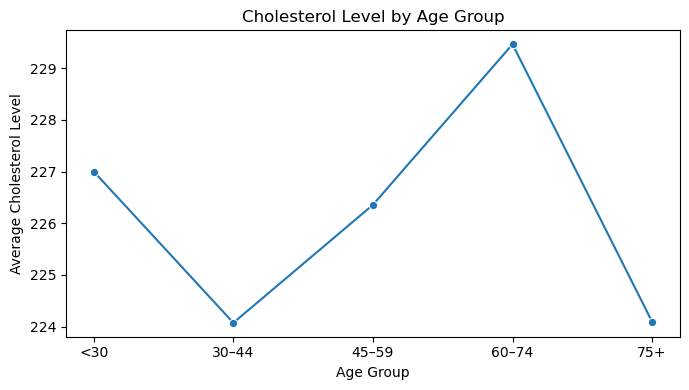

In [69]:
cholesterol_by_age = df.groupby('Age_Group', observed=True)['Cholesterol_Level'].mean().reset_index()

plt.figure(figsize=(7, 4))
sns.lineplot(x='Age_Group', y='Cholesterol_Level', data=cholesterol_by_age, marker='o')
plt.title('Cholesterol Level by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Cholesterol Level')
plt.tight_layout()
plt.show()

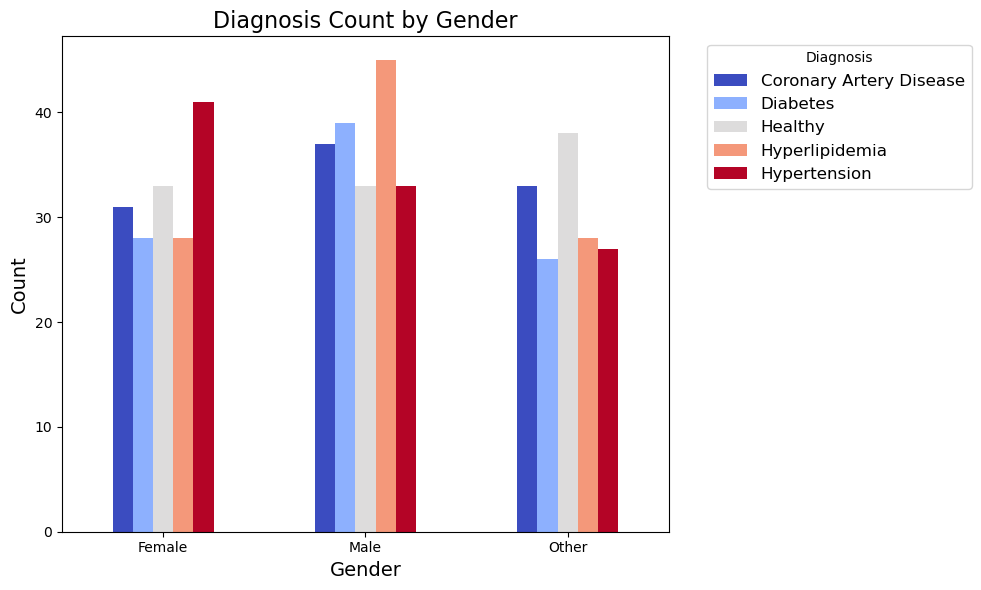

In [78]:
# Create the crosstab
diagnosis_by_gender = pd.crosstab(df['Gender'], df['Diagnosis'])

# Plotting the grouped bar plot
ax = diagnosis_by_gender.plot(kind='bar', figsize=(10, 6), cmap='coolwarm')
plt.title('Diagnosis Count by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()


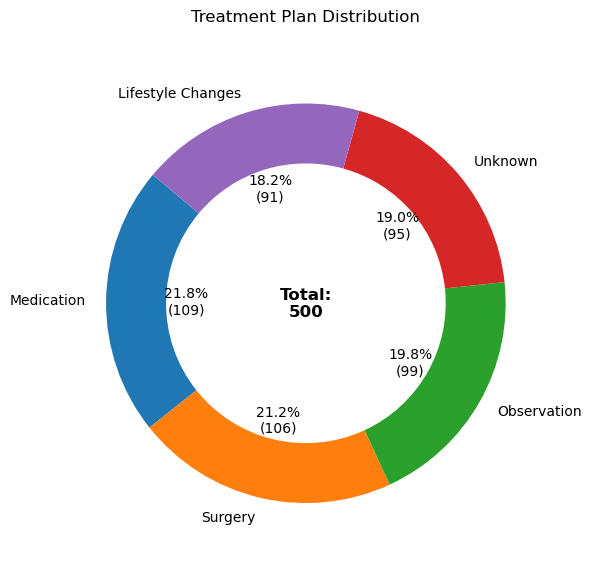

In [86]:
# Plotting doughnut chart
treatment_counts = df['Treatment_Plan'].value_counts()

# Format labels with both % and count
def format_label(pct, allvals):
    absolute = int(round(pct / 100. * sum(allvals)))
    return f"{pct:.1f}%\n({absolute})"
    
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    treatment_counts,
    labels = treatment_counts.index,
    autopct=lambda pct: format_label(pct, treatment_counts),
    startangle=140,
    wedgeprops={'width': 0.3}
)
# Add a central label
plt.text(0, 0, f'Total:\n{treatment_counts.sum()}', 
         horizontalalignment='center', verticalalignment='center',
         fontsize=12, fontweight='bold')
plt.title('Treatment Plan Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [88]:
# Summary stats by diagnosis
summary = df.groupby('Diagnosis', observed = True).agg({
    'Age': 'mean',
    'BMI': 'mean',
    'Cholesterol_Level': 'mean',
    'Patient_ID': 'count'
}).rename(columns={'Patient_ID': 'Patient_Count'})

summary = summary.round(1)
print(summary)

                          Age   BMI  Cholesterol_Level  Patient_Count
Diagnosis                                                            
Coronary Artery Disease  49.3  28.2              226.9            101
Diabetes                 43.0  29.8              212.4             93
Healthy                  53.6  30.4              230.3            104
Hyperlipidemia           48.9  29.5              224.0            101
Hypertension             49.0  29.2              234.2            101


<Figure size 1000x600 with 0 Axes>

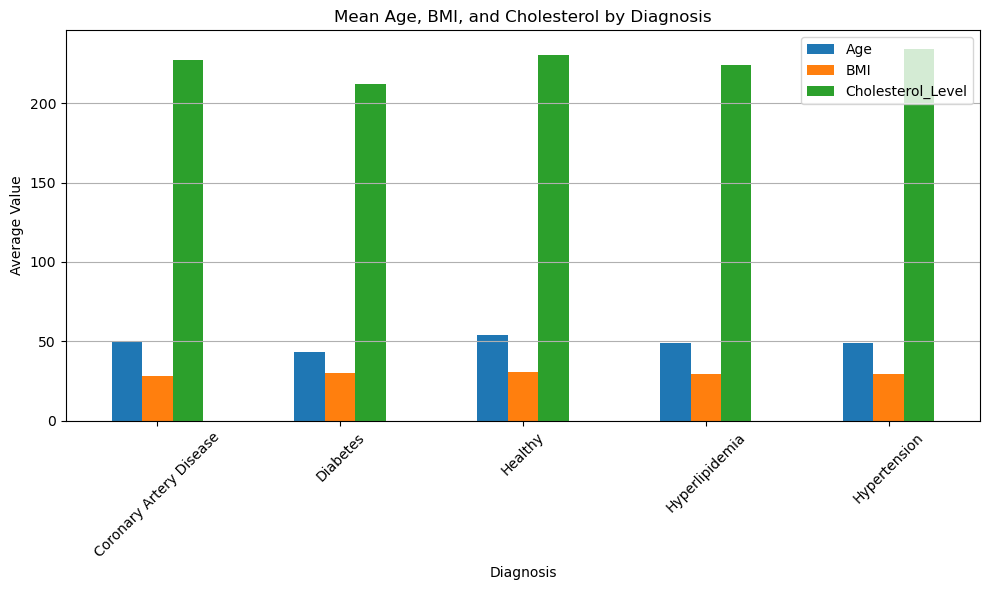

In [93]:
plt.figure(figsize=(10, 6))
summary[['Age', 'BMI', 'Cholesterol_Level']].plot(kind='bar', figsize=(10, 6))
plt.title("Mean Age, BMI, and Cholesterol by Diagnosis")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [96]:
# Save summary to CSV
# summary.to_csv("Diagnosis_Insights_Summary.csv")
# print("CSV file saved.")